In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


In [40]:
df_hist = pd.read_excel('EAL_Linking_Data.xlsx',sheet_name='Historic schedule',header=4)
df_fut  = pd.read_excel('EAL_Linking_Data.xlsx',sheet_name='Future schedule',header=4)


In [41]:
df_hist.head(15)

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival / Departure,Aircraft Type,Airline,Origin / Destination
0,2023-06-01 00:00:00,Commercial,2719556,2655707,A,C,FR,VLC
1,2023-06-01 00:05:00,Commercial,2719557,2655734,A,C,FR,KUN
2,2023-06-01 00:15:00,Commercial,2655685,2719558,A,C,FR,OPO
3,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM
4,2023-06-01 01:10:00,Cargo,2742844,2655967,A,C,NPT,STN
5,2023-06-01 01:15:00,Commercial,2655689,2655723,A,C,LS,TFS
6,2023-06-01 01:20:00,Commercial,2749224,2655728,A,C,U2,ATH
7,2023-06-01 01:25:00,Commercial,2655690,2655715,A,C,U2,HER
8,2023-06-01 01:30:00,Cargo,2655691,2655983,A,C,NPT,EMA
9,2023-06-01 01:40:00,Commercial,2717735,2655722,A,C,LS,ACE


In [4]:
df_hist.dtypes

Date and Time           datetime64[us]
Passenger/Cargo                    str
Flight ID                        int64
Turnaround Flight ID             int64
Arrival / Departure                str
Aircraft Type                      str
Airline                            str
Origin / Destination               str
dtype: object

In [5]:
df_hist.describe()

,Date and Time,Flight ID,Turnaround Flight ID
count,92942,9.294200e+04,9.294200e+04
mean,2024-08-07 18:33:32.805620,2.950753e+06,2.950803e+06
min,2023-06-01 00:00:00,2.655685e+06,2.655356e+06
25%,2023-08-16 19:27:30,2.745041e+06,2.745051e+06
50%,2024-07-25 07:37:30,2.913792e+06,2.913810e+06
75%,2025-06-28 12:18:45,3.149943e+06,3.149949e+06
max,2025-08-31 23:40:00,3.329637e+06,3.330341e+06
std,NaN,1.994793e+05,1.994913e+05


# Stat Descriptives

In [6]:
df_hist['hour']        = df_hist['Date and Time'].dt.hour          # 0–23
df_hist['minute']      = df_hist['Date and Time'].dt.minute        # 0–59
df_hist['weekday']     = df_hist['Date and Time'].dt.dayofweek     # 0=Lundi, 6=Dimanche
df_hist['weekday_name']= df_hist['Date and Time'].dt.day_name()   # 'Monday'...
df_hist['day']         = df_hist['Date and Time'].dt.day           # 1–31
df_hist['month']       = df_hist['Date and Time'].dt.month         # 1–12
df_hist['month_name']  = df_hist['Date and Time'].dt.month_name()  # 'June'...
df_hist['quarter']     = df_hist['Date and Time'].dt.quarter       # 1–4
df_hist['year']        = df_hist['Date and Time'].dt.year
df_hist['week']        = df_hist['Date and Time'].dt.isocalendar().week  # Semaine ISO
df_hist['is_weekend']  = df_hist['weekday'].isin([5, 6]).astype(int)

In [7]:
# Heure cyclique
df_hist['hour_sin'] = np.sin(2 * np.pi * df_hist['hour'] / 24)
df_hist['hour_cos'] = np.cos(2 * np.pi * df_hist['hour'] / 24)

# Mois cyclique
df_hist['month_sin'] = np.sin(2 * np.pi * df_hist['month'] / 12)
df_hist['month_cos'] = np.cos(2 * np.pi * df_hist['month'] / 12)

# Jour de semaine cyclique
df_hist['weekday_sin'] = np.sin(2 * np.pi * df_hist['weekday'] / 7)
df_hist['weekday_cos'] = np.cos(2 * np.pi * df_hist['weekday'] / 7)

Date and Time
2023-12-31    27704
2024-12-31    31889
2025-12-31    33349
Freq: YE-DEC, dtype: int64

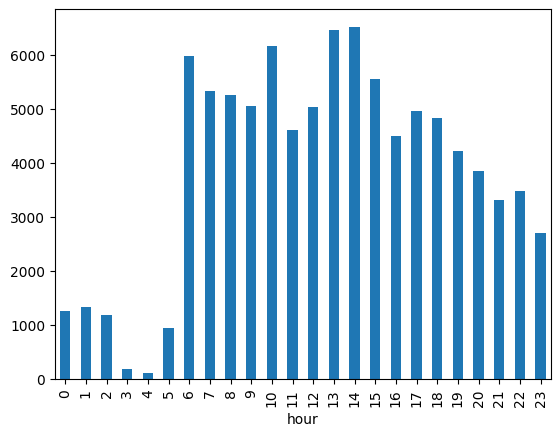

In [8]:
# Volume par heure
df_hist.groupby('hour').size().plot(kind='bar')

# Volume par jour de semaine
df_hist.groupby('weekday_name').size()

# Saisonnalité mensuelle
df_hist.groupby('month').size()

# Tendance dans le temps (resample)
df_hist.set_index('Date and Time').resample('ME').size()   # par jour
df_hist.set_index('Date and Time').resample('QE').size()   # par semaine
df_hist.set_index('Date and Time').resample('YE').size()   # par mois

In [9]:
df_hist['Aircraft Type'].value_counts()

Aircraft Type
C    82957
D     4117
B     3883
E     1975
A       10
Name: count, dtype: int64

In [10]:
df_hist['Arrival / Departure' ].value_counts()

Arrival / Departure
D    46480
A    46462
Name: count, dtype: int64

In [11]:
df_hist['Passenger/Cargo'].value_counts()

Passenger/Cargo
Commercial     88605
Cargo           3178
Positioning     1159
Name: count, dtype: int64

In [29]:
df_hist['Origin / Destination'].value_counts(normalize=True)


Origin / Destination
LHR    0.056325
DUB    0.055680
AMS    0.036614
STN    0.036485
CDG    0.029965
         ...   
JED    0.000011
RDU    0.000011
XFW    0.000011
BGR    0.000011
VIT    0.000011
Name: proportion, Length: 222, dtype: float64

# Feature engineering

In [34]:
df_hist.isna().sum()

Date and Time           0
Passenger/Cargo         0
Flight ID               0
Turnaround Flight ID    0
Arrival / Departure     0
Aircraft Type           0
Airline                 0
Origin / Destination    0
hour                    0
minute                  0
weekday                 0
weekday_name            0
day                     0
month                   0
month_name              0
quarter                 0
year                    0
week                    0
is_weekend              0
hour_sin                0
hour_cos                0
month_sin               0
month_cos               0
weekday_sin             0
weekday_cos             0
dtype: int64

Je veux construire un modele qui peut s'entrainer sur ces données pour que dans le futrure, quand y'a un avion
qui arrive, et que sur le schedule y'a des vols de départs, dans 3h, 1H, 30 min....., le modele va attribuer des 
scores de probabilité de correspondance entre les vols d'arrivées et les vols de départs, en se basant sur les 
caractéristiques des vols et les données historiques de correspondances réussies pour a la fin predire cet avion qui est arrivé va partir dans quel vol futur.


In [42]:
df_hist.head()

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival / Departure,Aircraft Type,Airline,Origin / Destination
0,2023-06-01 00:00:00,Commercial,2719556,2655707,A,C,FR,VLC
1,2023-06-01 00:05:00,Commercial,2719557,2655734,A,C,FR,KUN
2,2023-06-01 00:15:00,Commercial,2655685,2719558,A,C,FR,OPO
3,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM
4,2023-06-01 01:10:00,Cargo,2742844,2655967,A,C,NPT,STN


Faut entrainer le modele sur des liens, donc faut identifier les vols qui ont les memes id

In [43]:
df_arr = df_hist[df_hist['Arrival / Departure'] == 'A']
df_dep = df_hist[df_hist['Arrival / Departure'] == 'D']

# Paires positives via Turnaround Flight ID
df_merged = df_arr.merge(
    df_dep,
    left_on='Turnaround Flight ID',
    right_on='Flight ID',
    suffixes=('_arr', '_dep')
)

In [ ]:
df_merged.columns

In [ ]:
# display all columns
pd.set_option('display.max_columns', None)
df_merged.head()

In [47]:
from datetime import timedelta

negatives = []

for _, arr in df_arr.iterrows():
    heure_arr = arr['Date and Time']
    vrai_turnaround = arr['Turnaround Flight ID']
    
    # Trouver tous les départs dans ±3h
    mask = (
        (df_dep['Date and Time'] >= heure_arr) &
        (df_dep['Date and Time'] <= heure_arr + timedelta(hours=3)) &
        (df_dep['Flight ID'] != vrai_turnaround)  # exclure le vrai
    )
    
    faux_departs = df_dep[mask]
    
    # Prendre 1 faux départ aléatoire (pour équilibrer)
    if len(faux_departs) > 0:
        neg = faux_departs.sample(1)
        neg['Flight ID_arr'] = arr['Flight ID']
        negatives.append(neg)

df_negatives = pd.concat(negatives)
df_negatives['label'] = 0

In [48]:
df_negatives.head()

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival / Departure,Aircraft Type,Airline,Origin / Destination,Flight ID_arr,label
15,2023-06-01 02:50:00,Positioning,2773821,2655696,D,C,NPT,EMA,2719556,0
16,2023-06-01 02:55:00,Cargo,2655698,2767174,D,B,LM,INV,2719557,0
16,2023-06-01 02:55:00,Cargo,2655698,2767174,D,B,LM,INV,2655685,0
16,2023-06-01 02:55:00,Cargo,2655698,2767174,D,B,LM,INV,2655686,0
16,2023-06-01 02:55:00,Cargo,2655698,2767174,D,B,LM,INV,2742844,0


## Create Turnaround Time (Hours)

In [49]:
# Temps du turnaround
df_merged['Turnaround Time'] = df_merged['Date and Time_dep'] - df_merged['Date and Time_arr']

In [57]:
df_merged['Turnaround Time'] = (
    df_merged['Date and Time_dep'] - df_merged['Date and Time_arr']
).dt.total_seconds() / 3600

In [58]:
df_merged['Turnaround Time'].describe()

count    46367.000000
mean         3.031224
std          6.339986
min        -12.916667
25%          0.583333
50%          0.833333
75%          3.000000
max        313.166667
Name: Turnaround Time, dtype: float64

### Encodage de Cargo/Passenger avec one hot encoding

In [ ]:

df_merged['Passenger/Cargo_arr'].value_counts(normalize=True)*100


Passenger/Cargo_arr
Commercial     95.345828
Cargo           3.530528
Positioning     1.123644
Name: proportion, dtype: float64

Cargo and Positioning flights represent less than 5% of the dataset combined, which could introduce bias in our model. To address this, we create a dummy equal to 1 if the flight is Commercial and 0 otherwise

In [74]:
df_merged['is_commercial_arr'] = (df_merged['Passenger/Cargo_arr'] == 'Commercial').astype(int)
df_merged['is_commercial_dep'] = (df_merged['Passenger/Cargo_dep'] == 'Commercial').astype(int)


for Arrival / Departure, after the merge the colmuns are either D or A, so we can keep only one

In [73]:
df_merged.drop(columns=['Arrival / Departure_arr', 'Arrival / Departure_dep'], inplace=True)

In [80]:
df_merged.drop(columns=['Aircraft Type_dep'], inplace=True)
df_merged.rename(columns={'Aircraft Type_arr': 'Aircraft Type'}, inplace=True)

In [82]:
df_merged['Aircraft Type'].value_counts()

Aircraft Type
C    41388
D     2058
B     1931
E      986
A        4
Name: count, dtype: int64

## Aircraft Categories

- **Category A**: less than 169 km/h (91 knots) indicated airspeed (IAS)  
- **Category B**: 169 km/h (91 knots) or more but less than 224 km/h (121 knots) IAS  
- **Category C**: 224 km/h (121 knots) or more but less than 261 km/h (141 knots) IAS  
- **Category D**: 261 km/h (141 knots) or more but less than 307 km/h (166 knots) IAS  
- **Category E**: 307 km/h (166 knots) or more but less than 391 km/h (211 knots) IAS  
- **Category H**: Helicopters

WIKIPEDIA

SO it's in an order, from lower to higher , wen can map the categories from 1 to 5

In [83]:
size_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
df_merged['Aircraft Size'] = df_merged['Aircraft Type'].map(size_map)
df_merged.drop(columns=['Aircraft Type'], inplace=True)

## Origin / Destination
#### Creating pairs from departure to arrival, to see special patterns in turnaround when there is specific pairs

In [ ]:
# Paire de routes arr → dep
df_merged['route_pair'] = (
    df_merged['Origin / Destination_arr'] + '_' + df_merged['Origin / Destination_dep']
)

# Frequency encoding
freq_route = df_merged['route_pair'].value_counts(normalize=True)*100
df_merged['route_pair_freq'] = df_merged['route_pair'].map(freq_route)

## Airline

In [96]:
(df_merged['Airline_arr']==df_merged['Airline_dep']).all()

np.False_

In [98]:
df_merged['Airline_arr'].nunique(), df_merged['Airline_dep'].nunique()

(76, 78)

In [99]:
(df_merged['Airline_arr'] != df_merged['Airline_dep']).sum()

np.int64(141)

In [104]:
df_merged[df_merged['Airline_arr'] != df_merged['Airline_dep']][['Airline_arr', 'Airline_dep']].value_counts()

Airline_arr  Airline_dep
RK           FR             58
FR           RK             57
FX           3V              4
NPT          7J              4
SWN          NPT             3
3V           FX              3
U2           EC              2
FX           ABR             2
7J           NPT             2
EC           U2              1
EI           EA              1
NPT          SWN             1
QY           D0              1
SIG          LM              1
ZT           S6              1
Name: count, dtype: int64

## Mapper les DEP_ARR et calculer leurs frequences

In [110]:
df_merged['airline_pair'] = df_merged['Airline_arr'] + '_' + df_merged['Airline_dep']

freq_pair = df_merged['airline_pair'].value_counts(normalize=True)
df_merged['airline_pair_freq'] = df_merged['airline_pair'].map(freq_pair)

df_merged.drop(columns=['Airline_arr', 'Airline_dep', 'airline_pair'], inplace=True)

In [111]:
df_merged['route_pair_freq'].describe()

count    46367.000000
mean         1.043018
std          1.593792
min          0.002157
25%          0.032351
50%          0.217827
75%          1.507538
max          5.622533
Name: route_pair_freq, dtype: float64

In [113]:
df_merged.head()

,Date and Time_arr,Passenger/Cargo_arr,Flight ID_arr,Turnaround Flight ID_arr,Origin / Destination_arr,Date and Time_dep,Passenger/Cargo_dep,Flight ID_dep,Turnaround Flight ID_dep,Origin / Destination_dep,Turnaround Time,is_commercial_arr,is_commercial_dep,Aircraft Size,route_pair,route_pair_freq,same_airline,airline_pair_freq
0,2023-06-01 00:00:00,Commercial,2719556,2655707,VLC,2023-06-01 06:10:00,Commercial,2655707,2719556,ACE,6.166667,1,1,3,VLC_ACE,0.019410,1,0.203895
1,2023-06-01 00:05:00,Commercial,2719557,2655734,KUN,2023-06-01 07:40:00,Commercial,2655734,2719557,PMI,7.583333,1,1,3,KUN_PMI,0.006470,1,0.203895
2,2023-06-01 00:15:00,Commercial,2655685,2719558,OPO,2023-06-01 07:00:00,Commercial,2719558,2655685,BRI,6.750000,1,1,3,OPO_BRI,0.002157,1,0.203895
3,2023-06-01 00:30:00,Commercial,2655686,2655729,DLM,2023-06-01 07:00:00,Commercial,2655729,2655686,NCE,6.500000,1,1,3,DLM_NCE,0.021567,1,0.206979
4,2023-06-01 01:10:00,Cargo,2742844,2655967,STN,2023-06-01 21:40:00,Cargo,2655967,2742844,STN,20.500000,0,0,3,STN_STN,1.507538,1,0.021567
